# Plots for presentation

In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

In [3]:
import pandas as pd

In [4]:
item_type = 'music'

In [5]:
model_list = ['llama3b','qwen', 'qwen3b','mistral','phi']

In [15]:
# baseline files - missing qwen 3b, phi running for more layers, alphas
model_dict = {
            'llama3b':'meta-llama/Llama-3.2-3B-Instruct', 
            'tinyllama':'TinyLlama-1.1B-Chat-v1.0',
            'mistral':"Mistral-7B-Instruct-v0.2",
            'qwen':'Qwen2.5-7B-Instruct',
            'phi': 'Phi-3-mini-128k-instruct',
            'qwen3b':'Qwen2.5-3B'}
if item_type == 'movie':
    baseline_files_dict = {
        'llama3b':'output_data/movie/logit_outputs/baseline_ndcg_llama3b_10.json',
        'mistral':'output_data/movie/logit_outputs/baseline_ndcg_mistral_26_1.0.json',
        'phi':'output_data/movie/logit_outputs/baseline_ndcg_phi_28_1.0.json',
        'qwen3b':'output_data/movie/logit_outputs/baseline_ndcg_qwen3b_26_1.0.json',
        'qwen':'output_data/movie/logit_outputs/baseline_ndcg_qwen_26_1.0.json'
    }
elif item_type == 'music':
    baseline_files_dict = {
        'llama3b': 'output_data/music/logit_outputs/baseline_ndcg_llama3b.json',
        'qwen3b': 'output_data/music/logit_outputs/baseline_ndcg_qwen3b_26_1.0.json'

    }


In [7]:
# Load baseline files into dicts
baseline_results_dict = {}
for model_name, file_str in baseline_files_dict.items():
    try:
        # print(file_str+suffix)
        with open(file_str, 'r', encoding='utf-8') as file:
        # Use json.load() to deserialize the file's content
            print('Loading file', file_str)
            s_data = json.load(file)
    except:
        # print('file not available')
        s_data = None
    baseline_results_dict[model_name] = s_data

Loading file output_data/music/logit_outputs/baseline_ndcg_llama3b.json
Loading file output_data/music/logit_outputs/baseline_ndcg_qwen3b_26_1.0.json


In [8]:
# Make dict to dataframe
rows = []
for model_name, b_data in baseline_results_dict.items():
    for user_id, user_data in b_data.items():
        gender = user_data["user_gender"]
        
        for k, ndcg in user_data["ndcg_results"].items():
            rows.append({
                "model": model_name,
                "user_id": user_id,
                "user_gender": gender,
                "k": int(k),
                "ndcg": ndcg
            })

    bdf = pd.DataFrame(rows)

In [9]:
bl_df = bdf.groupby(['model','user_gender','k'])['ndcg'].mean().reset_index()
bl_df_wide = bl_df.pivot(
    index=['model','k'], 
    columns='user_gender', 
    values='ndcg').reset_index()

In [10]:
bl_df_wide.columns

Index(['model', 'k', 'female', 'male'], dtype='object', name='user_gender')

In [11]:
if item_type == 'movie':
    bl_df_wide['diff'] = bl_df_wide['M']-bl_df_wide['F']
elif item_type =='music':
    bl_df_wide['diff'] = bl_df_wide['male']-bl_df_wide['female']


In [16]:
bl_df_wide['full_model_str'] = bl_df_wide['model'].map(model_dict)

In [17]:
bl_df_wide.head()

user_gender,model,k,female,male,diff,full_model_str
0,llama3b,1,0.434757,0.490812,0.056055,meta-llama/Llama-3.2-3B-Instruct
1,llama3b,2,0.546413,0.576250,0.029837,meta-llama/Llama-3.2-3B-Instruct
2,llama3b,3,0.604638,0.646694,0.042056,meta-llama/Llama-3.2-3B-Instruct
3,llama3b,4,0.656534,0.696022,0.039488,meta-llama/Llama-3.2-3B-Instruct
4,llama3b,5,0.698911,0.734556,0.035646,meta-llama/Llama-3.2-3B-Instruct


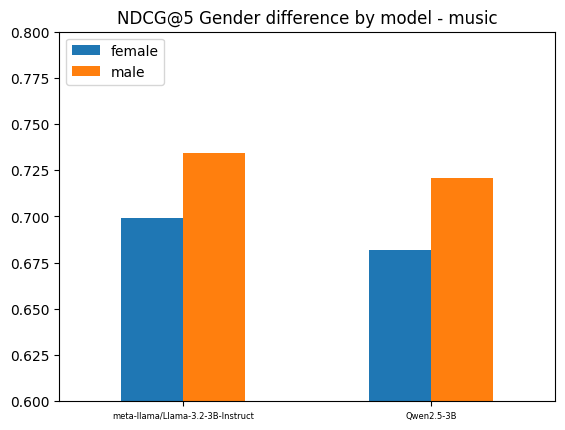

In [18]:
# Plot for k=5
k=5
ax = bl_df_wide[bl_df_wide['k']==k].plot(x='full_model_str', y=['female','male'], kind='bar')
# ax.bar_label(ax.containers, labels=bl_df_wide['diff'])
plt.ylim(0.6,0.8)
plt.title(f'NDCG@{k} Gender difference by model - {item_type}')
plt.xticks(fontsize=6)

plt.xlabel('', fontsize=4)

ax.tick_params(axis='x', labelrotation=0)
ax.legend(loc='upper left')


In [ ]:
# Plot baseline NDCG@5 and NDCG@10 for baseline across multiple models


## Plot AUC by layer

In [74]:
# Plot AUC by layer for different models
model_name = 'llama3b'
item_type = 'movie'
log_reg_type = 'reg'
n = 747
regress_dict = {}
file_path = f'output_data/{item_type}/embeddings/embed_{n}_{model_name}.pkl'
with open(file_path, 'rb') as file:
    embedding_data_dict = pickle.load(file)

[{'demo': {'gender': 'M', 'age_group': '35_44', 'age_binary': 'older'},
  'hidden': tensor([-0.0069, -0.0204, -0.0562,  ..., -0.0718,  0.0187,  0.0332],
         dtype=torch.bfloat16)},
 {'demo': {'gender': 'M', 'age_group': '25_34', 'age_binary': 'younger'},
  'hidden': tensor([ 0.0070, -0.0284, -0.1191,  ..., -0.0173,  0.0369,  0.0090],
         dtype=torch.bfloat16)},
 {'demo': {'gender': 'M', 'age_group': '18_24', 'age_binary': 'younger'},
  'hidden': tensor([-0.0003,  0.0008, -0.0952,  ..., -0.0713, -0.0021,  0.0214],
         dtype=torch.bfloat16)},
 {'demo': {'gender': 'F', 'age_group': '45_54', 'age_binary': 'older'},
  'hidden': tensor([-0.0015, -0.0498, -0.0083,  ..., -0.0454,  0.0117,  0.0483],
         dtype=torch.bfloat16)},
 {'demo': {'gender': 'M', 'age_group': '18_24', 'age_binary': 'younger'},
  'hidden': tensor([ 0.0177, -0.0177, -0.0530,  ..., -0.1064,  0.0148,  0.0226],
         dtype=torch.bfloat16)},
 {'demo': {'gender': 'M', 'age_group': '55_', 'age_binary': 'old